In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

np.random.seed(42)

# ── YOUR REAL STATS ───────────────────────────────────────
ACCOUNT        = 10_000
RISK_PCT       = 0.01     # 1% per trade
TRADES_PM      = 16       # trades per month
MONTHS         = 12       # projection horizon

# Live trading stats (16 real trades)
LIVE_WR        = 0.625
LIVE_AVG_WIN   = 2.46
LIVE_AVG_LOSS  = -1.00
LIVE_EXP       = 1.91

# Scenarios
SCENARIOS = {
    "Bear Case"  : {"wr": 0.45, "avg_w": 1.50,
                    "avg_l": -1.00},
    "Base Case"  : {"wr": 0.55, "avg_w": 2.00,
                    "avg_l": -1.00},
    "Live Stats" : {"wr": 0.625,"avg_w": 2.46,
                    "avg_l": -1.00},
    "Bull Case"  : {"wr": 0.70, "avg_w": 2.80,
                    "avg_l": -1.00},
}

print("Monte Carlo Account Growth Projector")
print("=" * 45)
print(f"Starting account : ${ACCOUNT:,}")
print(f"Risk per trade   : {RISK_PCT:.0%} "
      f"(${ACCOUNT*RISK_PCT:.0f})")
print(f"Trades per month : {TRADES_PM}")
print(f"Projection       : {MONTHS} months")
print(f"Simulations      : 10,000 per scenario")
print(f"\nScenarios:")
for name, s in SCENARIOS.items():
    exp = (s['wr']*s['avg_w']) + \
          ((1-s['wr'])*s['avg_l'])
    print(f"  {name:<12}: WR={s['wr']:.0%} "
          f"AvgW={s['avg_w']:.2f}R "
          f"Exp={exp:+.2f}R/trade")

Monte Carlo Account Growth Projector
Starting account : $10,000
Risk per trade   : 1% ($100)
Trades per month : 16
Projection       : 12 months
Simulations      : 10,000 per scenario

Scenarios:
  Bear Case   : WR=45% AvgW=1.50R Exp=+0.12R/trade
  Base Case   : WR=55% AvgW=2.00R Exp=+0.65R/trade
  Live Stats  : WR=62% AvgW=2.46R Exp=+1.16R/trade
  Bull Case   : WR=70% AvgW=2.80R Exp=+1.66R/trade


In [2]:
def simulate_account(account, risk_pct, wr, avg_w,
                     avg_l, trades_pm, months,
                     n_sims=10000):
    """
    Monte Carlo simulation of account growth.
    Each trade risks risk_pct of current account.
    Returns matrix of equity paths (n_sims x total_trades)
    """
    total_trades = trades_pm * months
    results      = np.zeros((n_sims, total_trades + 1))
    results[:, 0] = account

    for sim in range(n_sims):
        balance = account
        for t in range(total_trades):
            risk_usd = balance * risk_pct
            # Simulate trade outcome
            if np.random.random() < wr:
                # Win — random R between 1.0 and avg_w*1.5
                r = np.random.uniform(1.0, avg_w * 1.5)
                balance += risk_usd * r
            else:
                # Loss — always -1R (your discipline)
                balance += risk_usd * avg_l
            balance = max(balance, 0)  # no negative
            results[sim, t+1] = balance

    return results

# Run simulations for all scenarios
print("Running 10,000 simulations per scenario...")
print("(This will take ~30 seconds)")
sim_results = {}

for name, s in SCENARIOS.items():
    print(f"  Simulating {name}...")
    sim_results[name] = simulate_account(
        account   = ACCOUNT,
        risk_pct  = RISK_PCT,
        wr        = s['wr'],
        avg_w     = s['avg_w'],
        avg_l     = s['avg_l'],
        trades_pm = TRADES_PM,
        months    = MONTHS,
        n_sims    = 10000
    )

print("\nSimulations complete")
print(f"{'='*60}")
print(f"  {'Scenario':<14} {'Median':>10} {'10th %':>10} "
      f"{'90th %':>10} {'Ruin%':>8}")
print(f"  {'-'*55}")

for name, res in sim_results.items():
    final     = res[:, -1]
    median    = np.median(final)
    p10       = np.percentile(final, 10)
    p90       = np.percentile(final, 90)
    ruin      = (final < ACCOUNT * 0.5).mean()
    print(f"  {name:<14} ${median:>9,.0f} "
          f"${p10:>9,.0f} "
          f"${p90:>9,.0f} "
          f"{ruin:>8.1%}")

print(f"{'='*60}")
print(f"\n  Ruin% = probability of losing >50% of account")
print(f"  10th% = worst 10% of outcomes")
print(f"  90th% = best 10% of outcomes")

Running 10,000 simulations per scenario...
(This will take ~30 seconds)
  Simulating Bear Case...
  Simulating Base Case...
  Simulating Live Stats...
  Simulating Bull Case...

Simulations complete
  Scenario           Median     10th %     90th %    Ruin%
  -------------------------------------------------------
  Bear Case      $   13,953 $   10,986 $   17,666     0.0%
  Base Case      $   33,960 $   25,673 $   44,619     0.0%
  Live Stats     $   78,032 $   57,449 $  106,026     0.0%
  Bull Case      $  174,916 $  128,045 $  241,054     0.0%

  Ruin% = probability of losing >50% of account
  10th% = worst 10% of outcomes
  90th% = best 10% of outcomes


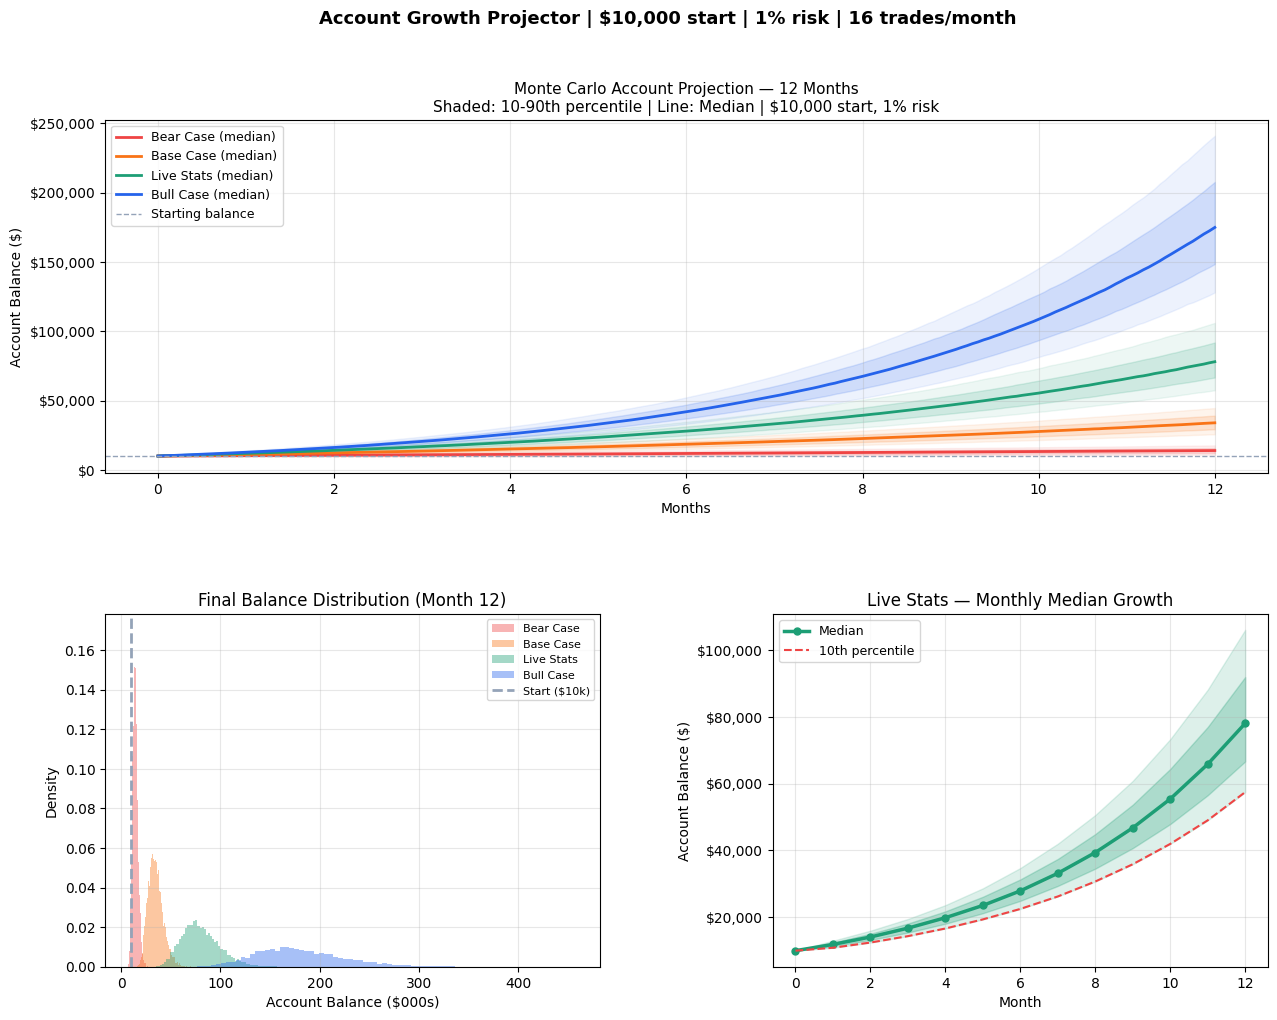

Chart saved to monte_carlo_projection.png


In [3]:
fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                         hspace=0.4, wspace=0.35)

colors = {
    "Bear Case" : "#ef4444",
    "Base Case" : "#f97316",
    "Live Stats": "#1D9E75",
    "Bull Case" : "#2563eb"
}

months_x = np.linspace(0, MONTHS,
                        TRADES_PM * MONTHS + 1)

# ── Panel 1: Equity fan chart ────────────────────────────
ax1 = fig.add_subplot(gs[0, :])

for name, res in sim_results.items():
    col = colors[name]
    p10 = np.percentile(res, 10, axis=0)
    p25 = np.percentile(res, 25, axis=0)
    p50 = np.percentile(res, 50, axis=0)
    p75 = np.percentile(res, 75, axis=0)
    p90 = np.percentile(res, 90, axis=0)

    ax1.fill_between(months_x, p10, p90,
                     alpha=0.08, color=col)
    ax1.fill_between(months_x, p25, p75,
                     alpha=0.15, color=col)
    ax1.plot(months_x, p50, color=col,
             lw=2, label=f'{name} (median)')

ax1.axhline(ACCOUNT, color='#94a3b8',
            lw=1, linestyle='--',
            label='Starting balance')
ax1.set_title('Monte Carlo Account Projection — 12 Months\n'
              'Shaded: 10-90th percentile | '
              'Line: Median | $10,000 start, 1% risk',
              fontsize=11)
ax1.set_xlabel('Months')
ax1.set_ylabel('Account Balance ($)')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Final balance distribution ─────────────────
ax2 = fig.add_subplot(gs[1, 0])
for name, res in sim_results.items():
    final = res[:, -1]
    ax2.hist(final/1000, bins=80, alpha=0.4,
             color=colors[name],
             label=name, density=True)
ax2.axvline(ACCOUNT/1000, color='#94a3b8',
            lw=2, linestyle='--',
            label='Start ($10k)')
ax2.set_title('Final Balance Distribution (Month 12)')
ax2.set_xlabel('Account Balance ($000s)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Monthly growth Live Stats ───────────────────
ax3 = fig.add_subplot(gs[1, 1])
live_res  = sim_results["Live Stats"]
n_months  = MONTHS
tpm       = TRADES_PM
month_idx = [i * tpm for i in range(n_months + 1)]
monthly   = live_res[:, month_idx]

m_p10 = np.percentile(monthly, 10, axis=0)
m_p25 = np.percentile(monthly, 25, axis=0)
m_p50 = np.percentile(monthly, 50, axis=0)
m_p75 = np.percentile(monthly, 75, axis=0)
m_p90 = np.percentile(monthly, 90, axis=0)

ax3.fill_between(range(n_months+1), m_p10, m_p90,
                  alpha=0.15, color='#1D9E75')
ax3.fill_between(range(n_months+1), m_p25, m_p75,
                  alpha=0.25, color='#1D9E75')
ax3.plot(range(n_months+1), m_p50,
         color='#1D9E75', lw=2.5,
         marker='o', markersize=5,
         label='Median')
ax3.plot(range(n_months+1), m_p10,
         color='#ef4444', lw=1.5,
         linestyle='--', label='10th percentile')

ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax3.set_title('Live Stats — Monthly Median Growth')
ax3.set_xlabel('Month')
ax3.set_ylabel('Account Balance ($)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle(
    f'Account Growth Projector | '
    f'${ACCOUNT:,} start | '
    f'{RISK_PCT:.0%} risk | '
    f'{TRADES_PM} trades/month',
    fontsize=13, fontweight='bold')

plt.savefig('monte_carlo_projection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to monte_carlo_projection.png")

In [4]:
# Monthly milestone table — Live Stats scenario
live_res  = sim_results["Live Stats"]
tpm       = TRADES_PM

print(f"\n{'='*65}")
print(f"  LIVE STATS SCENARIO — MONTHLY MILESTONES")
print(f"  ($10,000 start | 1% risk | 16 trades/month)")
print(f"{'='*65}")
print(f"  {'Month':<8} {'Median':>10} {'10th%':>10} "
      f"{'90th%':>10} {'Growth':>8}")
print(f"  {'-'*60}")

prev_median = ACCOUNT
for m in range(1, MONTHS + 1):
    idx    = m * tpm
    final  = live_res[:, idx]
    median = np.median(final)
    p10    = np.percentile(final, 10)
    p90    = np.percentile(final, 90)
    growth = (median - ACCOUNT) / ACCOUNT
    print(f"  Month {m:<3} ${median:>9,.0f} "
          f"${p10:>9,.0f} "
          f"${p90:>9,.0f} "
          f"{growth:>8.0%}")

print(f"{'='*65}")

# Risk scaling analysis
# What happens when you scale to 2% at month 3?
print(f"\n{'='*65}")
print(f"  RISK SCALING SCENARIO")
print(f"  Start at 1% → Scale to 2% after 3 months")
print(f"  (if WR stays above 55% for first 3 months)")
print(f"{'='*65}")

n_sims    = 10000
scale_res = np.zeros((n_sims, TRADES_PM*MONTHS + 1))
scale_res[:, 0] = ACCOUNT

s = SCENARIOS["Live Stats"]
for sim in range(n_sims):
    balance = ACCOUNT
    for t in range(TRADES_PM * MONTHS):
        month      = t // TRADES_PM
        risk_pct   = 0.02 if month >= 3 else 0.01
        risk_usd   = balance * risk_pct
        if np.random.random() < s['wr']:
            r       = np.random.uniform(1.0,
                                        s['avg_w']*1.5)
            balance += risk_usd * r
        else:
            balance += risk_usd * s['avg_l']
        balance = max(balance, 0)
        scale_res[sim, t+1] = balance

final_1pct  = live_res[:, -1]
final_scale = scale_res[:, -1]

print(f"\n  Strategy          Median      10th%     90th%")
print(f"  {'-'*55}")
print(f"  Stay at 1%     "
      f"${np.median(final_1pct):>9,.0f}  "
      f"${np.percentile(final_1pct,10):>9,.0f}  "
      f"${np.percentile(final_1pct,90):>9,.0f}")
print(f"  Scale to 2%    "
      f"${np.median(final_scale):>9,.0f}  "
      f"${np.percentile(final_scale,10):>9,.0f}  "
      f"${np.percentile(final_scale,90):>9,.0f}")
print(f"\n  Extra median gain from scaling: "
      f"${np.median(final_scale)-np.median(final_1pct):,.0f}")
print(f"{'='*65}")


  LIVE STATS SCENARIO — MONTHLY MILESTONES
  ($10,000 start | 1% risk | 16 trades/month)
  Month        Median      10th%      90th%   Growth
  ------------------------------------------------------------
  Month 1   $   11,874 $   10,875 $   12,979      19%
  Month 2   $   14,092 $   12,433 $   15,982      41%
  Month 3   $   16,743 $   14,353 $   19,486      67%
  Month 4   $   19,862 $   16,637 $   23,634      99%
  Month 5   $   23,534 $   19,360 $   28,659     135%
  Month 6   $   27,898 $   22,494 $   34,734     179%
  Month 7   $   33,157 $   26,224 $   42,005     232%
  Month 8   $   39,374 $   30,699 $   50,589     294%
  Month 9   $   46,758 $   35,866 $   60,820     368%
  Month 10  $   55,406 $   41,954 $   73,286     454%
  Month 11  $   65,820 $   49,011 $   88,107     558%
  Month 12  $   78,032 $   57,449 $  106,026     680%

  RISK SCALING SCENARIO
  Start at 1% → Scale to 2% after 3 months
  (if WR stays above 55% for first 3 months)

  Strategy          Median      